# 1. Text exploration — MulTaBench core text

Audit the **20 official core TEXT datasets** before any Jev call. Focus on text-column counts, lengths, missing inputs, exact duplicates and the amount of reusable extraction. All source versions and text-column lists are pinned in `config/exploration/datasets.yaml`.

## 1. Scope and provenance

The public CSVs and metadata are loaded at pinned versions. Missing data can be downloaded when `allow_download: true`; existing data are hash-checked. No model code or weights are loaded. See `docs/DATA_SOURCES.md` for the official text definition and audit denominators. Each notebook runs independently.


In [1]:
import sys
from pathlib import Path
REPO_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").is_file() and (p / "src").is_dir())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.utils.config import load_config, save_resolved_config
from src.utils.notebook_display import display_local, display_json
from src.utils.provenance import provenance
from src.data.audit import audit_collection
from src.visualize import figures, style
style.apply()
cfg = load_config()
from src.data.audit import audit_summary
from src.visualize.audit import burden_figures
from src.visualize.exploration import dataset_overview, overview_figure, text_column_figures, reuse_figure
import matplotlib.pyplot as plt

NOTEBOOK = "exploration/01_data_exploration"
from src.utils.notebook_report import begin_report, report_section, finish_report
begin_report()
report_section('1. Scope and provenance')
save = figures.FigureSaver(NOTEBOOK)
config_hash = save_resolved_config(cfg, NOTEBOOK)
display_json("Execution provenance", provenance())
audit = audit_collection(cfg)


## 2. Dataset overview

One row per dataset. Feature counts exclude the target. Binary versus multiclass is determined from the official classification task and observed distinct class vocabulary; numerical targets are not automatically treated as regression. Class vocabulary may be inspected below; no frequencies enter request metadata.


The overview includes all 20 datasets, counts, mean nonempty text length, missing text, and exact reuse in counts and percentages. The large figure is intended for screen inspection or large-format export; it should not be shrunk onto a paper page. The same complete overview is saved as `overview.csv`.

,dataset,task_type,target,n_classes,rows,columns_including_target,features,text_columns,non_text_columns,mean_characters_per_nonempty_text,...,per_column_missing_or_empty_pct,per_column_unique_inputs,per_column_repeated_inputs,per_column_reuse_savings_pct,joint_missing_or_empty_pct,joint_unique_inputs,joint_repeated_inputs,joint_reuse_savings_pct,combined_unique_inputs,combined_tokens_p95
0,Fake Job Postings,binary_classification,fraudulent,2.0,12725,6,5,3,2,591.43,...,27.76,21958,5619,20.38,0.00,12674,51,0.40,34631,734.00
1,Jigsaw Toxicity,binary_classification,Is Toxic,2.0,100000,32,31,1,30,297.38,...,0.00,99661,338,0.34,0.00,99661,338,0.34,99661,239.00
2,Kickstarter,binary_classification,Funding Status,2.0,86502,10,9,3,6,74.45,...,0.00,258820,679,0.26,0.00,86502,0,0.00,345321,120.00
3,Data Scientist Salary,multiclass_classification,salary,6.0,15841,7,6,5,1,42.74,...,4.43,30594,45102,59.58,0.00,12074,3767,23.78,42668,66.00
4,Michelin Guide,multiclass_classification,Award,5.0,18843,12,11,6,5,118.26,...,0.99,63756,48186,43.05,0.00,18843,0,0.00,82599,271.00
5,Product Sentiment,multiclass_classification,Sentiment,4.0,5091,3,2,1,1,104.47,...,0.00,5084,7,0.14,0.00,5084,7,0.14,5084,36.00
6,Spotify Genres,multiclass_classification,track_genre,114.0,114000,19,18,3,15,18.14,...,0.00,151634,190363,55.66,0.00,89379,24620,21.60,241013,27.00
7,US Accidents,multiclass_classification,Severity,4.0,100001,45,44,6,38,17.90,...,0.08,170390,429133,71.58,0.00,96585,3416,3.42,266975,42.00
8,Wine Review,multiclass_classification,variety,30.0,84123,6,5,2,3,126.52,...,0.02,79356,88857,52.82,0.00,78995,5128,6.10,158319,93.00
9,Women's Clothing,multiclass_classification,Rating,5.0,18788,11,10,2,8,174.48,...,9.93,29605,4241,12.53,3.54,18119,3,0.02,45326,133.00


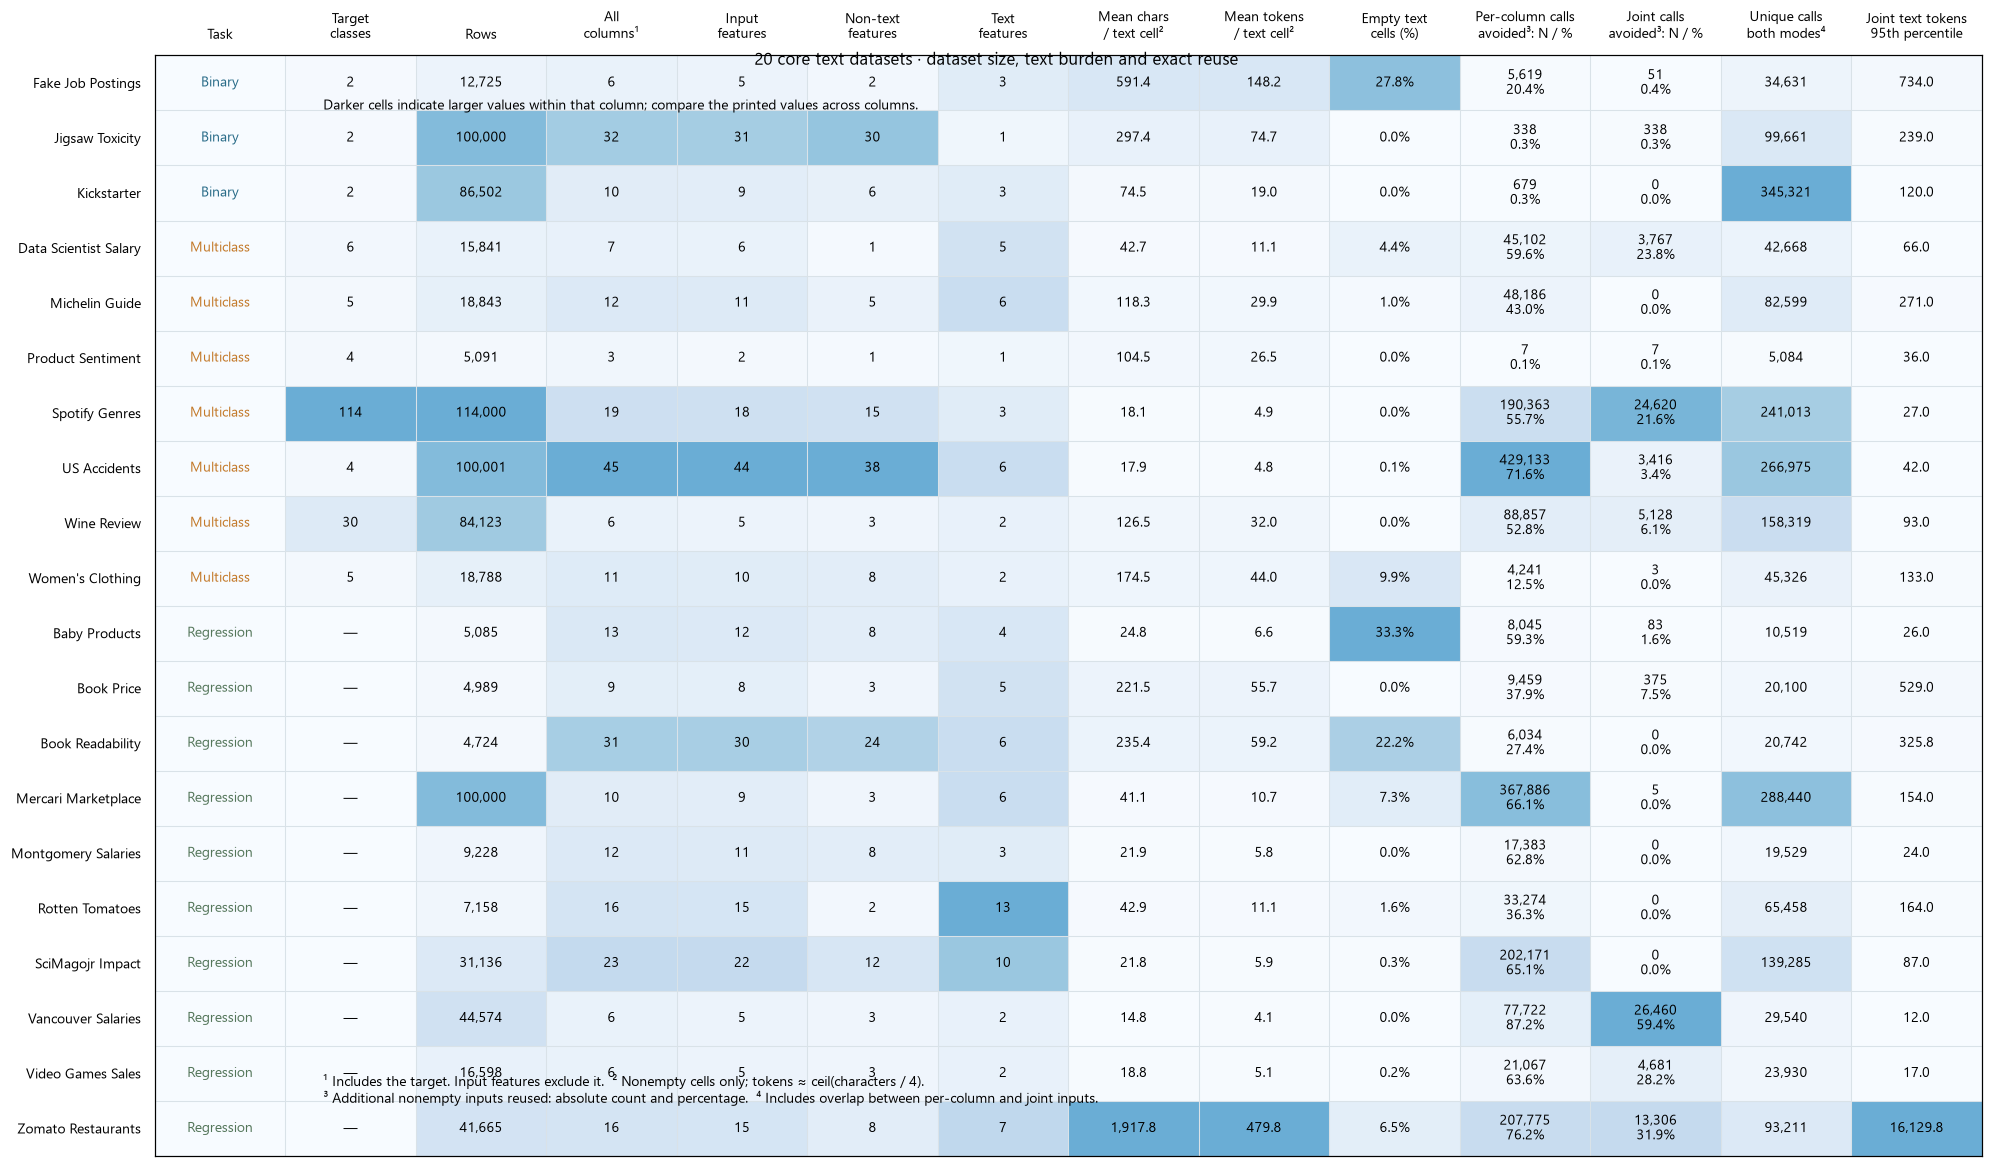

In [2]:
report_section('2. Dataset overview')
overview = dataset_overview(audit)
display_local(overview.round(2))
overview.to_csv(audit.folder / "overview.csv", index=False)
fig, name, caption = overview_figure(overview, cfg["token_estimation"]["characters_per_token"])
save(fig, name, caption=caption)
display_local(fig)
plt.close(fig)
for dataset_id in audit.summary.dataset_id:
    display_json(audit.metadata(dataset_id).dataset_name + " — task metadata", audit.details[dataset_id]["task_metadata"])


## 3. Individual text columns: length, missingness and repetition

One row per official text column. `nonempty_characters_mean` excludes null/whitespace-only inputs; the existing character/token statistics include them as zero. `unique_nonempty_inputs` counts the exact inputs that need a first response for this field. `repeated_nonempty_rows` counts the additional copies that can reuse it; `top_input_frequencies` lists the frequencies of the most common inputs without exposing their text.

Equality is exact: nonempty whitespace, capitalization, value type, and column names matter. Null, nonfinite and whitespace-only inputs share the agreed missing policy. The detailed audit below retains descriptive dtype/target statistics separately.


,dataset_id,feature,nonempty_characters_mean,characters_median,characters_p95,tokens_mean,tokens_p95,missing_pct,missing_or_empty_pct,nonempty_rows,unique_nonempty_inputs,unique_nonempty_ratio,repeated_nonempty_rows,top_input_frequencies
0,BIN_TEXT_FAKE_JOB_POSTING,title,28.315992,26.0,57.0,7.452338,15.0,0.000000,0.000000,12725,9240,0.726130,3485,"[107, 62, 57, 53, 51]"
1,BIN_TEXT_FAKE_JOB_POSTING,salary_range,10.380460,0.0,11.0,0.485658,3.0,83.269155,83.269155,2129,755,0.354627,1374,"[110, 44, 36, 26, 25]"
2,BIN_TEXT_FAKE_JOB_POSTING,description,1251.867956,1058.0,2910.6,313.291081,728.0,0.007859,0.015717,12723,11963,0.940266,760,"[25, 18, 18, 17, 16]"
3,BIN_TEXT_JIGSAW_TOXICITY,comment_text,297.383234,202.0,953.0,74.718090,239.0,0.001000,0.001000,99999,99661,0.996620,338,"[16, 9, 8, 8, 7]"
4,BIN_TEXT_KICKSTARTER_FUNDING,name,53.673414,37.0,289.0,13.797404,73.0,0.001156,0.001156,86501,86313,0.997827,188,"[5, 4, 4, 3, 3]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,REG_TEXT_ZOMATO_RESTAURANTS,phone,20.026364,14.0,30.0,5.280619,8.0,1.953678,1.953678,40851,12198,0.298597,28653,"[181, 61, 58, 57, 54]"
86,REG_TEXT_ZOMATO_RESTAURANTS,dish_liked,64.543730,21.0,98.0,9.301716,25.0,43.688948,43.688948,23462,5224,0.222658,18238,"[180, 68, 67, 66, 56]"
87,REG_TEXT_ZOMATO_RESTAURANTS,cuisines,24.703726,21.0,48.0,6.533349,12.0,0.026401,0.026401,41654,2383,0.057209,39271,"[2158, 1980, 1234, 642, 615]"
88,REG_TEXT_ZOMATO_RESTAURANTS,reviews_list,11720.977631,1754.0,63561.6,2930.622345,15890.4,0.000000,0.000000,41665,21272,0.510548,20393,"[1121, 21, 20, 20, 19]"


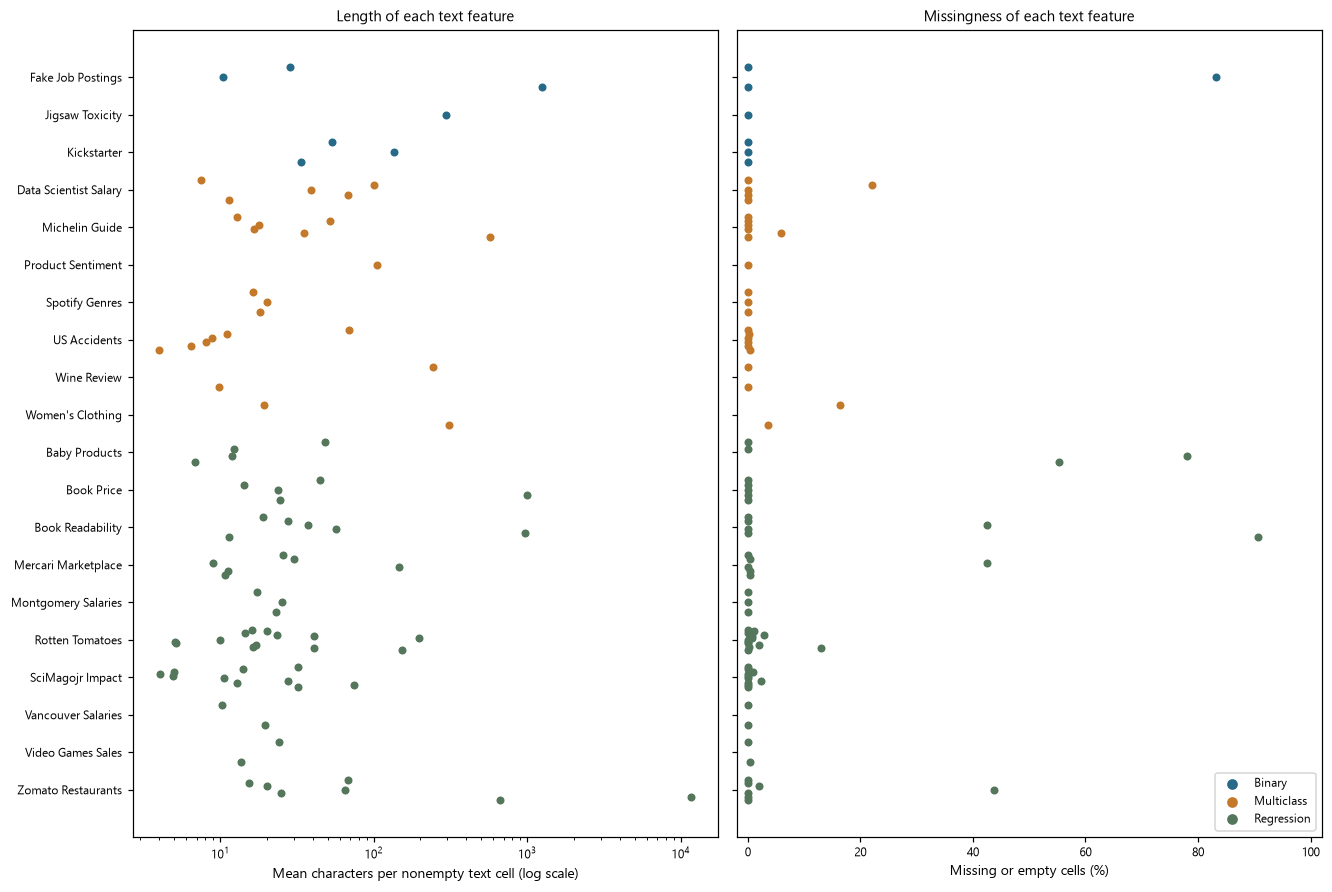

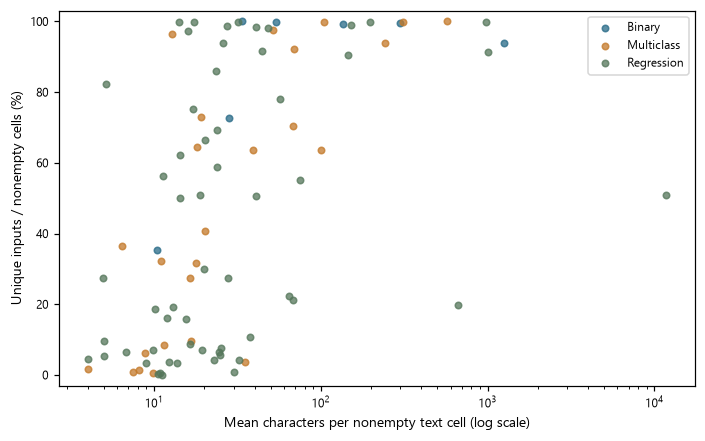

In [3]:
report_section('3. Individual text columns: length, missingness and repetition')
display_local(audit.text[["dataset_id", "feature", "nonempty_characters_mean", "characters_median", "characters_p95", "tokens_mean", "tokens_p95", "missing_pct", "missing_or_empty_pct", "nonempty_rows", "unique_nonempty_inputs", "unique_nonempty_ratio", "repeated_nonempty_rows", "top_input_frequencies"]])

for fig, name, caption in text_column_figures(audit):
    save(fig, name, caption=caption)
    display_local(fig)
    plt.close(fig)


## 4. Joint duplicates and total reusable extraction

Joint equality compares **all named available text fields together**, omitting missing fields. Count this directly; do not assume every joint row is unique. `joint_single_field_unique_overlap` counts joint inputs that equal a per-column input because only one field is available.

`combined_unique_inputs = per_column_unique_inputs + joint_unique_inputs - joint_single_field_unique_overlap`.

These are exact counts for fixed task metadata, question, model and configuration. They describe requests to obtain and cache once, not the number of numeric feature columns. Identical complete requests reuse the first saved response. We have not tested whether repeating a paid call returns exactly the same probabilities; cache reuse does not require this guarantee. No target values enter the matching.


,dataset,rows,text_columns,per_column_nonempty_inputs,per_column_unique_inputs,per_column_reuse_savings_pct,joint_nonempty_inputs,joint_unique_inputs,joint_unique_ratio,joint_reuse_savings_pct,joint_missing_or_empty_pct,joint_single_field_unique_overlap,combined_unique_inputs
0,Fake Job Postings,12725,3,27577,21958,20.375675,12725,12674,0.995992,0.400786,0.000000,1,34631
1,Jigsaw Toxicity,100000,1,99999,99661,0.338003,99999,99661,0.996620,0.338003,0.001000,99661,99661
2,Kickstarter,86502,3,259499,258820,0.261658,86502,86502,1.000000,0.000000,0.000000,1,345321
3,Data Scientist Salary,15841,5,75696,30594,59.583069,15841,12074,0.762199,23.780064,0.000000,0,42668
4,Michelin Guide,18843,6,111942,63756,43.045506,18843,18843,1.000000,0.000000,0.000000,0,82599
5,Product Sentiment,5091,1,5091,5084,0.137498,5091,5084,0.998625,0.137498,0.000000,5084,5084
6,Spotify Genres,114000,3,341997,151634,55.662184,113999,89379,0.784033,21.596681,0.000877,0,241013
7,US Accidents,100001,6,599523,170390,71.579072,100001,96585,0.965840,3.415966,0.000000,0,266975
8,Wine Review,84123,2,168213,79356,52.824098,84123,78995,0.939042,6.095836,0.000000,32,158319
9,Women's Clothing,18788,2,33846,29605,12.530284,18122,18119,0.999834,0.016554,3.544816,2398,45326


,dataset_id,mode,text_columns,rows,nonempty_rows,missing_or_empty_rows,missing_or_empty_pct,unique_nonempty_inputs,unique_nonempty_ratio,repeated_nonempty_rows,reuse_savings_pct,repeated_distinct_inputs,rows_in_repeated_groups,most_common_input_count,top_input_frequencies
3,BIN_TEXT_FAKE_JOB_POSTING,joint,"[title, salary_range, description]",12725,12725,0,0.000000,12674,0.995992,51,0.400786,49,100,3,"[3, 3, 2, 2, 2]"
5,BIN_TEXT_JIGSAW_TOXICITY,joint,[comment_text],100000,99999,1,0.001000,99661,0.996620,338,0.338003,202,540,16,"[16, 9, 8, 8, 7]"
9,BIN_TEXT_KICKSTARTER_FUNDING,joint,"[name, desc, keywords]",86502,86502,0,0.000000,86502,1.000000,0,0.000000,0,0,1,"[1, 1, 1, 1, 1]"
15,MUL_TEXT_DATA_SCIENTIST_SALARY,joint,"[experience, job_description, job_desig, key_s...",15841,15841,0,0.000000,12074,0.762199,3767,23.780064,3061,6828,10,"[10, 9, 8, 8, 8]"
22,MUL_TEXT_MICHELIN_RESTAURANTS,joint,"[Name, Address, Location, Cuisine, FacilitiesA...",18843,18843,0,0.000000,18843,1.000000,0,0.000000,0,0,1,"[1, 1, 1, 1, 1]"
24,MUL_TEXT_PRODUCT_SENTIMENT,joint,[Product_Description],5091,5091,0,0.000000,5084,0.998625,7,0.137498,7,14,2,"[2, 2, 2, 2, 2]"
28,MUL_TEXT_SPOTIFY_GENRES,joint,"[artists, album_name, track_name]",114000,113999,1,0.000877,89379,0.784033,24620,21.596681,16795,41415,12,"[12, 10, 9, 9, 9]"
35,MUL_TEXT_US_ACCIDENTS,joint,"[Description, Street, City, County, Zipcode, A...",100001,100001,0,0.000000,96585,0.965840,3416,3.415966,2857,6273,10,"[10, 9, 8, 6, 6]"
38,MUL_TEXT_WINE_REVIEW,joint,"[description, province]",84123,84123,0,0.000000,78995,0.939042,5128,6.095836,5126,10254,3,"[3, 3, 2, 2, 2]"
41,MUL_TEXT_WOMEN_CLOTHING_REVIEW,joint,"[Title, Review Text]",18788,18122,666,3.544816,18119,0.999834,3,0.016554,2,5,3,"[3, 2, 1, 1, 1]"


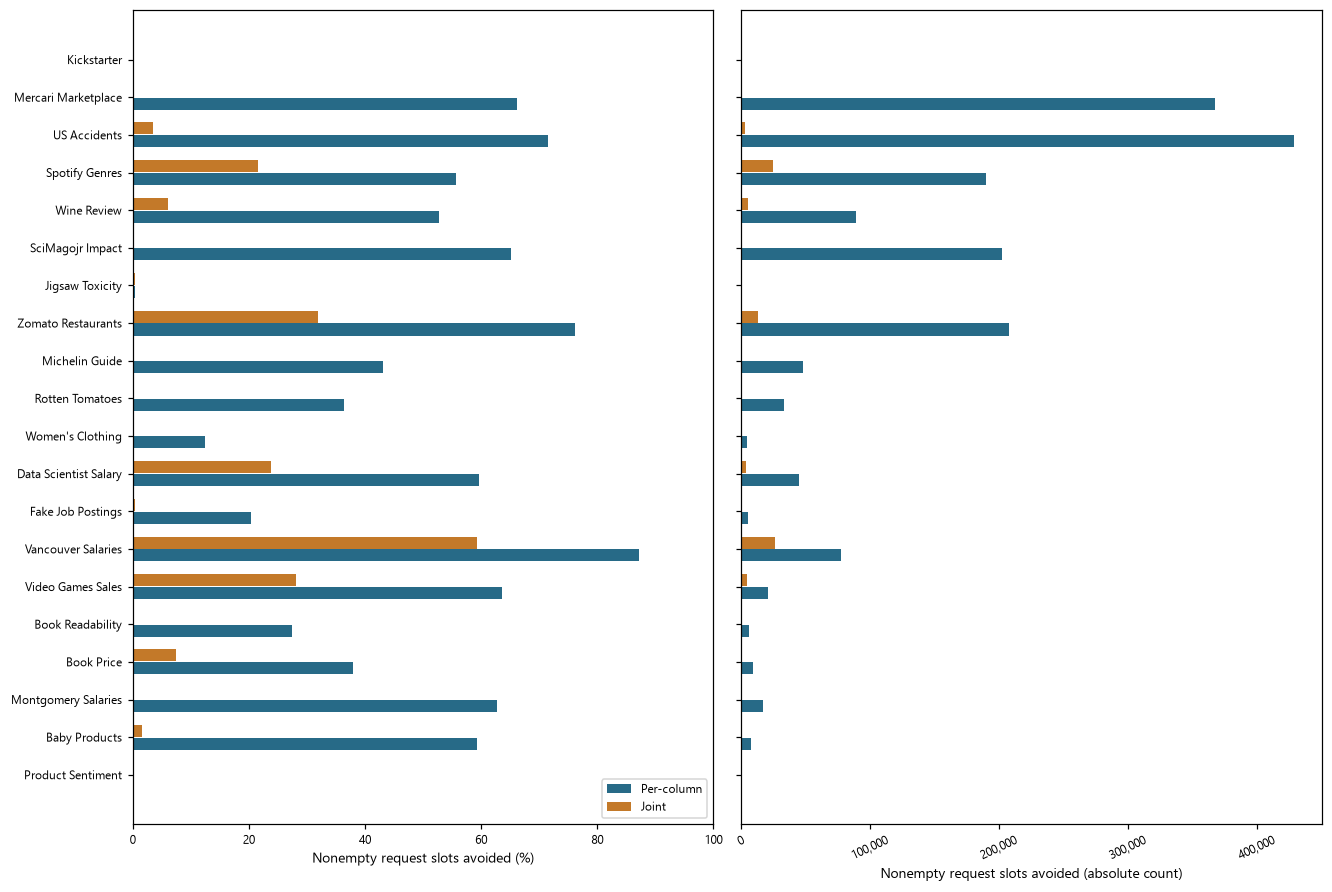

In [4]:
report_section('4. Joint duplicates and total reusable extraction')
display_local(audit.summary[["dataset", "rows", "text_columns", "per_column_nonempty_inputs", "per_column_unique_inputs", "per_column_reuse_savings_pct", "joint_nonempty_inputs", "joint_unique_inputs", "joint_unique_ratio", "joint_reuse_savings_pct", "joint_missing_or_empty_pct", "joint_single_field_unique_overlap", "combined_unique_inputs"]])
display_local(audit.reuse[audit.reuse["mode"] == "joint"])
fig, name, caption = reuse_figure(audit.summary)
save(fig, name, caption=caption)
display_local(fig)
plt.close(fig)


## 5. Full column and target audit

Expand a dataset to see **every feature**, missingness, unique counts/ratios, numeric statistics, categorical cardinalities/common values, text-length statistics and representative examples. Unique ratios use nonmissing rows as denominator. Character/word/token length statistics include missing text as empty, matching workload accounting. “Words” means whitespace-separated strings.

Tokens are approximated as `ceil(characters / 4)`, not measured with Jev’s tokenizer. Examples are unique nonempty values at deterministic length ranks near 10%, 50% and 90%, clipped only for display. Full request text is never clipped.

The target distribution or regression quantiles are **audit-only**. The request builder has no input for these statistics. “Other” includes date-like columns. Non-text feature classification uses the CSV dtype; no model preprocessing has been selected.

In [5]:
report_section('5. Full column and target audit')
for dataset_id in audit.summary.dataset_id:
    detail = audit.details[dataset_id]
    display_json(audit.metadata(dataset_id).dataset_name + " — full column audit", {
        "features": audit.columns[audit.columns.dataset_id == dataset_id].to_dict(orient="records"),
        "text_statistics": audit.text[audit.text.dataset_id == dataset_id].to_dict(orient="records"),
        "numeric_statistics": audit.numeric[audit.numeric.dataset_id == dataset_id].fillna("missing").to_dict(orient="records"),
        "categorical_statistics": audit.categorical[audit.categorical.dataset_id == dataset_id].to_dict(orient="records"),
        "text_examples": detail["text_examples"],
        "target_audit_only": detail["target_audit_only"],
        "issues": detail["issues"],
    })


## 6. Text burden

Combined row tokens use `ceil(sum(text characters) / 4)`. Notebook 2 adds metadata, question wording, class choices and JSON escaping. No non-text features enter Jev. Short strings and names count as text under the official annotation.


,dataset,text_columns,combined_tokens_mean,combined_tokens_median,combined_tokens_p95,combined_tokens_max,total_text_tokens
0,Fake Job Postings,3,320.803929,272.0,734.00,3736,4082230
1,Jigsaw Toxicity,1,74.718090,51.0,239.00,384,7471809
2,Kickstarter,3,56.216330,49.0,120.00,568,4862825
3,Data Scientist Salary,5,51.428066,55.0,66.00,85,814672
4,Michelin Guide,6,176.004617,168.0,271.00,427,3316455
5,Product Sentiment,1,26.497545,27.0,36.00,45,134899
6,Spotify Genres,3,13.983816,12.0,27.00,250,1594155
7,US Accidents,6,27.203458,26.0,42.00,139,2720373
8,Wine Review,2,63.624788,62.0,93.00,210,5352308
9,Women's Clothing,2,78.935438,78.0,133.00,139,1483039


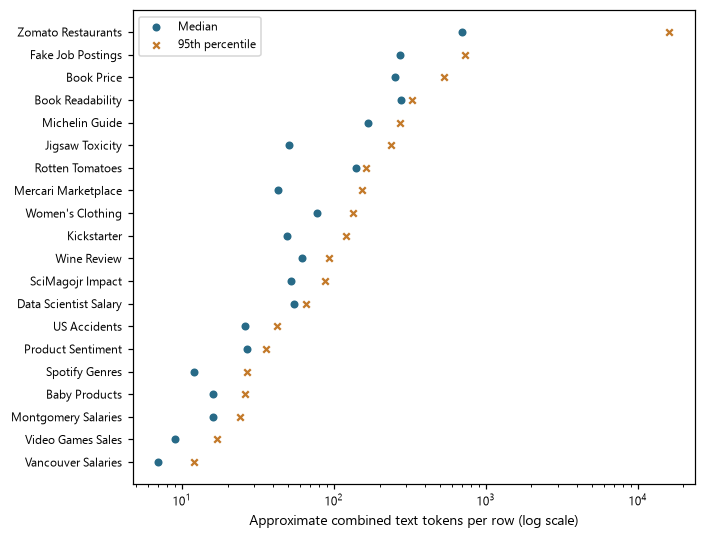

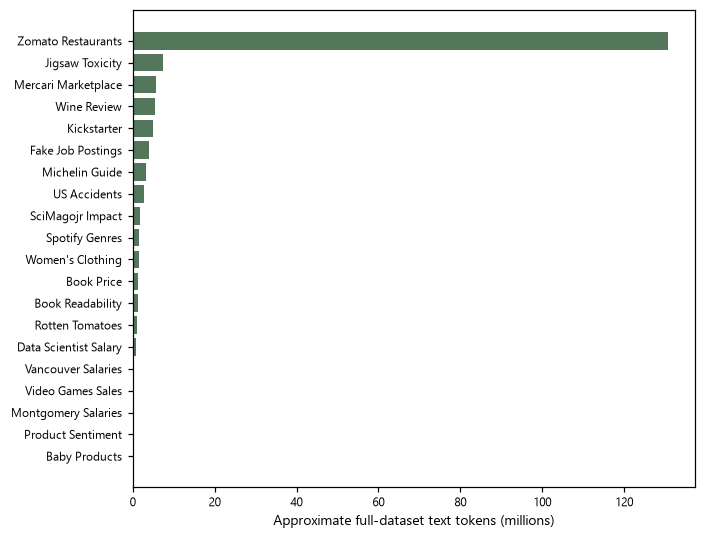

In [6]:
report_section('6. Text burden')
display_local(audit.summary[["dataset", "text_columns", "combined_tokens_mean", "combined_tokens_median", "combined_tokens_p95", "combined_tokens_max", "total_text_tokens"]])
for fig, name, caption in burden_figures(audit.summary, cfg["token_estimation"]["characters_per_token"]):
    save(fig, name, caption=caption)
    display_local(fig)
    plt.close(fig)


## 7. Saved outputs

CSV/JSON audits and encoded length arrays are under `output_JEVPFN/exploration/results/data_audit/`. Configurations are in that phase's `manifests/`. Figures are in `output_JEVPFN/figures/exploration/01_data_exploration/`, with `Captions.md`. The full final summary contains every displayed audit detail and plotted value, including local examples. Generated reports are gitignored; source notebooks remain output-free for GitHub.


In [7]:
report_section('7. Saved outputs')
display_json("Audit artifacts", {"directory": str(audit.folder), "tables": ["summary.csv", "columns.csv", "text.csv", "reuse.csv", "numeric.csv", "categorical.csv"], "config_sha256": config_hash})


## Summary

Section order matches the notebook. The notebook saves this complete text verbatim into `output_JEVPFN/All Results.md`.

In [8]:
finish_report(NOTEBOOK, audit_summary(audit) + "\n" + save.summary())


exploration/01_data_exploration

1. Scope and provenance


Execution provenance
{
  "code_sha256": "1aa9c0dd11296831c9efec3968aa39ccc884eb921b674786777ae368da74009e",
  "git_head": "ce9b7779a0ecaa0215e5988f080478d47b068156",
  "git_dirty": true,
  "tfm_library_pin": "81c749bdf17e88b5152f4dc7f2e49bd48e9cc8ba tfm-library (heads/main)",
  "environment": {
    "python": "3.12.10",
    "numpy": "2.5.3",
    "pandas": "2.3.3",
    "PyYAML": "6.0.3",
    "matplotlib": "3.11.2",
    "pyarrow": "25.0.1"
  }
}


2. Dataset overview

              dataset                 task_type                             target  n_classes   rows  columns_including_target  features  text_columns  non_text_columns  mean_characters_per_nonempty_text  mean_tokens_per_nonempty_text  per_column_missing_or_empty_pct  per_column_unique_inputs  per_column_repeated_inputs  per_column_reuse_savings_pct  joint_missing_or_empty_pct  joint_unique_inputs  joint_repeated_inputs  joint_reuse_savings_pct  combined_unique_input